# Análise Exploratória de Vendas de Videogames

**Disciplina:** Estatística | **Integrantes:**                                                                                                                         
- Arthur Sindeaux de Araújo Nogueira
- Guilherme Tolentino Leitão de Melo
- Rafael Coutinho Lima
- Lucas Pinto Ribeiro Beno
- Pedro Coutinho da Silva
- Arthur Oliveira Furieri
- João Henrique Bastos
- João Eduardo Azevedo de Andrade

## Problema principal

Analisar as vendas de títulos de videogame para entender como o desempenho comercial se distribui entre gêneros, plataformas e regiões.

## Perguntas de investigação e hipóteses

**Pergunta 1.** Como se distribui o desempenho comercial dos títulos, e quão concentrado está o mercado em poucos lançamentos?

*Hipótese 1:* a distribuição é fortemente assimétrica à direita, com média bastante superior à mediana e o terceiro quartil ainda em patamar baixo. Se confirmado, o jogo mediano vende uma fração do que a média sugere, e a média é uma métrica enganosa para planejar um lançamento.

**Pergunta 2.** O desempenho de um título em um mercado se repete nos demais, ou cada região tem dinâmica própria?

*Hipótese 2:* as receitas regionais não se movem juntas de forma uniforme. Esperamos divergência entre Pearson e Spearman, porque Pearson é dominado pelos poucos títulos gigantes enquanto Spearman descreve o jogo típico. Se as duas medidas apontarem direções diferentes, a previsibilidade entre mercados só existe na faixa dos grandes sucessos.

**Pergunta 3.** Gêneros e plataformas com mais lançamentos são também os de melhor desempenho típico?

*Hipótese 3:* volume de lançamentos não acompanha desempenho mediano. Esperamos que categorias mais exploradas apresentem mediana comprimida por saturação.

## Fonte dos dados

Dataset `vgsales.csv` (Video Game Sales, Kaggle), com estimativas de vendas em milhões de unidades. Cada linha representa **um jogo em uma plataforma específica**: o mesmo título lançado em dois consoles ocupa duas linhas.

# 1 Config do Ambiente

In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np


In [3]:
import sys
print(sys.executable)

/home/rafael-coutinho/Área de trabalho/ProjetoEstatistica/venv/bin/python


## 2. Carga e reconhecimento inicial dos dados

In [4]:
df = pd.read_csv("data/vgsales.csv")

print("Linhas e colunas:", df.shape)
df.head()
df.info()
df.describe()

Linhas e colunas: (16598, 11)
<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


**Leitura inicial.** A base tem 16.598 registros e 11 colunas. Já aparecem dois problemas a tratar: `Year` foi lida como decimal, o que é sintoma de valores ausentes, e as colunas de venda têm média muito distante do máximo, primeiro indício da assimetria que a Pergunta 1 investiga.

**Leitura inicial.** A base tem 16.598 registros e 11 colunas. Já aparecem dois problemas a tratar: `Year` foi lida como decimal, o que é sintoma de valores ausentes, e as colunas de venda têm média muito distante do máximo, primeiro indício da assimetria que a Pergunta 1 investiga.

## 3. Pré-processamento


In [5]:
nulos = pd.DataFrame({
    "ausentes": df.isnull().sum(),
    "percentual": (df.isnull().sum() / len(df) * 100).round(2)
})
nulos[nulos["ausentes"] > 0]

,ausentes,percentual
Year,271,1.63
Publisher,58,0.35


**Diagnóstico de nulos.** Apenas duas colunas têm ausências e ambas em volume pequeno: `Year` (1,63%) e `Publisher` (0,35%). Nenhuma coluna de vendas tem valor faltante, o que importa porque as perguntas de investigação dependem exclusivamente delas. Antes de aplicar o tratamento, verificamos as duplicatas: parte das linhas repetidas tem justamente `Year` ausente, e é preciso saber quais casos estão saindo da base por esse critério.

### 3.1 Tratamento de valores ausentes

Optamos por remover as linhas com valores ausentes em vez de imputar. `Year` representa 1,63% dos registros e não há como estimar um ano de lançamento sem inventar informação; `Publisher` são 0,35%. Somadas, a perda fica abaixo de 2% e nenhuma coluna de vendas é afetada, de modo que as medidas descritivas de `Global_Sales` permanecem íntegras.

In [6]:
antes = len(df)
df = df.dropna()
print(f"Removidas {antes - len(df)} linhas com valores ausentes. Restam {len(df)} registros.")
print(f"Perda: {(antes - len(df)) / antes * 100:.2f}%")
print("Nulos restantes:", df.isnull().sum().sum())

Removidas 307 linhas com valores ausentes. Restam 16291 registros.
Perda: 1.85%
Nulos restantes: 0


### 3.2 Duplicatas

O mesmo jogo em plataformas diferentes é legítimo (são linhas distintas). O que é erro de base é o mesmo título repetido na mesma plataforma e no mesmo ano, então usamos essa combinação como chave.

In [7]:
print("Linhas 100% iguais:", df.duplicated().sum())

chave = ["Name", "Platform", "Year"]
print("Duplicadas pela chave nome+plataforma+ano:", df.duplicated(subset=chave).sum())
df[df.duplicated(subset=chave, keep=False)]

Linhas 100% iguais: 0
Duplicadas pela chave nome+plataforma+ano: 1


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
603,604,Madden NFL 13,PS3,2012.0,Sports,Electronic Arts,2.11,0.23,0.0,0.22,2.56
16127,16130,Madden NFL 13,PS3,2012.0,Sports,Electronic Arts,0.00,0.01,0.0,0.00,0.01


A única duplicata encontrada foi *Madden NFL 13* no PS3 em 2012, com um registro de 2,56 M e outro de 0,01 M. Mantivemos o primeiro, que concentra praticamente toda a venda do título.

In [8]:
antes = len(df)
df = df.drop_duplicates(subset=chave, keep="first")
print(f"Removidas {antes - len(df)} duplicatas. Base final: {len(df)} registros")

Removidas 1 duplicatas. Base final: 16290 registros


### 3.3 Conversão de tipos

Com os nulos removidos, `Year` pode virar inteiro (antes era float justamente por causa dos NaN). As colunas de texto que representam categorias viram `category`.

In [9]:
df["Year"] = df["Year"].astype(int)
for col in ["Platform", "Genre", "Publisher"]:
    df[col] = df[col].astype("category")

df.dtypes

Rank               int64
Name                 str
Platform        category
Year               int64
Genre           category
Publisher       category
NA_Sales         float64
EU_Sales         float64
JP_Sales         float64
Other_Sales      float64
Global_Sales     float64
dtype: object

## 4. Distribuição das vendas globais (Pergunta 1)

Com a base tratada, passamos à pergunta 1. Começamos pelas
medidas de tendência central e de dispersão de `Global_Sales`, que já permitem
uma primeira leitura sobre a forma da distribuição.

In [10]:
vendas = df["Global_Sales"]

media   = vendas.mean()
mediana = vendas.median()
moda    = vendas.mode().iloc[0]
desvio  = vendas.std()
cv      = desvio / media * 100
Q1, Q3  = vendas.quantile([0.25, 0.75])
IQR     = Q3 - Q1

print(f"N:                {len(vendas)}")
print(f"Média:            {media:.3f} M")
print(f"Mediana (Q2):     {mediana:.3f} M")
print(f"Moda:             {moda:.3f} M")
print(f"Mínimo / Máximo:  {vendas.min():.2f} / {vendas.max():.2f} M")
print(f"Amplitude:        {vendas.max() - vendas.min():.2f} M")
print(f"Desvio-padrão:    {desvio:.3f}")
print(f"CV:               {cv:.1f}%")
print(f"Q1 / Q3 / IQR:    {Q1:.3f} / {Q3:.3f} / {IQR:.3f}")

N:                16290
Média:            0.541 M
Mediana (Q2):     0.170 M
Moda:             0.020 M
Mínimo / Máximo:  0.01 / 82.74 M
Amplitude:        82.73 M
Desvio-padrão:    1.567
CV:               289.8%
Q1 / Q3 / IQR:    0.060 / 0.480 / 0.420


### 4.1 Concentração do mercado

A segunda parte da pergunta é sobre concentração: quanto das vendas totais está em poucos títulos? Olhamos os percentis altos e a fatia dos Top N.

In [11]:
print(vendas.quantile([0.90, 0.95, 0.99]))

total = vendas.sum()
for n in [10, 100, 1000]:
    fatia = vendas.nlargest(n).sum() / total * 100
    print(f"Top {n}: {fatia:.1f}% das vendas ({n / len(vendas) * 100:.2f}% dos títulos)")

0.90    1.2200
0.95    2.0500
0.99    5.4722
Name: Global_Sales, dtype: float64
Top 10: 4.2% das vendas (0.06% dos títulos)
Top 100: 16.6% das vendas (0.61% dos títulos)
Top 1000: 48.5% das vendas (6.14% dos títulos)


### 4.2 Assimetria e curtose

Para confirmar numericamente o que a diferença entre média e mediana sugere.

In [12]:
print(f"Assimetria: {vendas.skew():.2f}")
print(f"Curtose:    {vendas.kurt():.2f}")
print("Moda de Genre:   ", df["Genre"].mode()[0])
print("Moda de Platform:", df["Platform"].mode()[0])

Assimetria: 17.30
Curtose:    595.97
Moda de Genre:    Action
Moda de Platform: DS


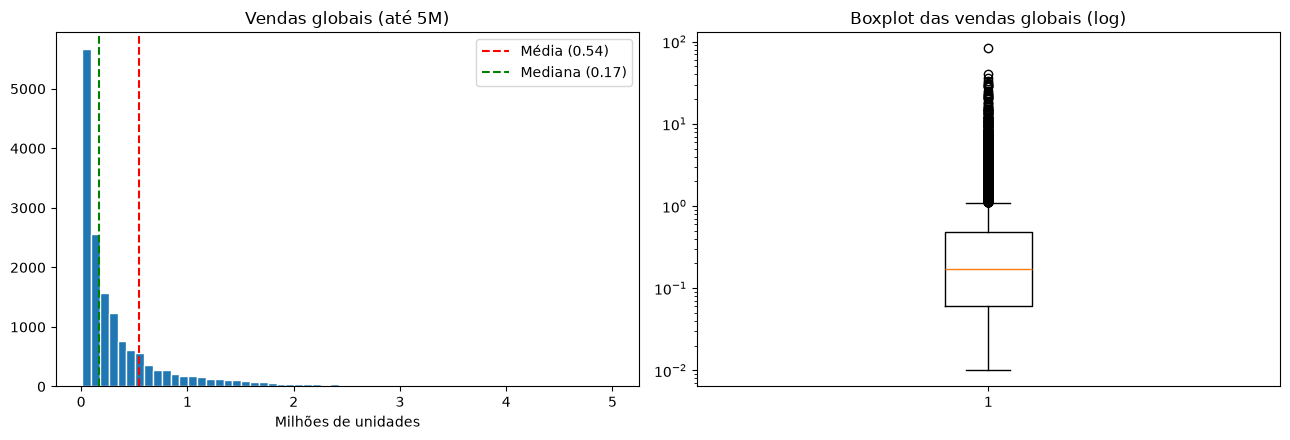

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].hist(vendas[vendas <= 5], bins=60, edgecolor="white")
ax[0].axvline(media, color="red", ls="--", label=f"Média ({media:.2f})")
ax[0].axvline(mediana, color="green", ls="--", label=f"Mediana ({mediana:.2f})")
ax[0].set_title("Vendas globais (até 5M)")
ax[0].set_xlabel("Milhões de unidades")
ax[0].legend()
ax[1].boxplot(vendas)
ax[1].set_yscale("log")
ax[1].set_title("Boxplot das vendas globais (log)")

plt.tight_layout()
plt.show()

**Conclusão da Pergunta 1.**

A média de vendas é 0,541 M, mas a mediana é apenas 0,170 M: a média é cerca de 3,2 vezes maior que o valor do título típico. Mais revelador ainda, o terceiro quartil (0,480 M) fica **abaixo da média**, ou seja, mais de 75% dos títulos vendem menos do que a média sugere. A moda (0,02 M) está praticamente colada no mínimo da base, mostrando que o resultado mais frequente é uma venda muito baixa.

A dispersão confirma a mesma leitura. O desvio padrão (1,567) é quase três vezes a média, com coeficiente de variação de 289,8%, e a amplitude vai de 0,01 a 82,74 M. A assimetria de 17,30 é extremamente positiva (acima de 1 já seria considerada forte) e a curtose de 595,97 indica uma distribuição leptocúrtica, com cauda muito mais pesada que a de uma normal. No boxplot, o limite superior (Q3 + 1,5 × IQR ≈ 1,11 M) fica abaixo do percentil 90 (1,22 M), então mais de 10% dos títulos aparecem como outliers.

A concentração é forte: os 100 maiores títulos (0,61% da base) respondem por 16,6% das vendas, e os 1.000 maiores (6,14%) por 48,5%, quase metade do mercado. Para entrar no top 1% é preciso vender mais de 5,47 M, um patamar 32 vezes acima da mediana.

**A Hipótese 1 se confirma.** A distribuição é fortemente assimétrica à direita e concentrada em poucos lançamentos. Na prática, a média não serve como referência para planejar um lançamento: ela é inflada pelos poucos sucessos gigantes, e o cenário realista para um título comum está próximo da mediana, em torno de 170 mil cópias.

## 5. O desempenho se repete entre regiões? (Pergunta 2)

Comparamos duas correlações. Pearson mede relação linear e é sensível a valores extremos, então tende a ser puxado pelos poucos títulos gigantes. Spearman trabalha com a posição (ranking) de cada título, e por isso descreve melhor o jogo típico. Se as duas divergirem, a relação entre mercados depende dos grandes sucessos.

In [14]:
regioes = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]

pearson  = df[regioes].corr(method="pearson")
spearman = df[regioes].corr(method="spearman")

print("Pearson:\n", pearson.round(2))
print("\nSpearman:\n", spearman.round(2))
print("\nDiferença (Pearson - Spearman):\n", (pearson - spearman).round(2))

Pearson:
              NA_Sales  EU_Sales  JP_Sales  Other_Sales
NA_Sales         1.00      0.77      0.45         0.63
EU_Sales         0.77      1.00      0.44         0.73
JP_Sales         0.45      0.44      1.00         0.29
Other_Sales      0.63      0.73      0.29         1.00

Spearman:
              NA_Sales  EU_Sales  JP_Sales  Other_Sales
NA_Sales         1.00      0.68     -0.23         0.77
EU_Sales         0.68      1.00     -0.18         0.77
JP_Sales        -0.23     -0.18      1.00        -0.07
Other_Sales      0.77      0.77     -0.07         1.00

Diferença (Pearson - Spearman):
              NA_Sales  EU_Sales  JP_Sales  Other_Sales
NA_Sales         0.00      0.09      0.68        -0.14
EU_Sales         0.09      0.00      0.61        -0.04
JP_Sales         0.68      0.61      0.00         0.36
Other_Sales     -0.14     -0.04      0.36         0.00


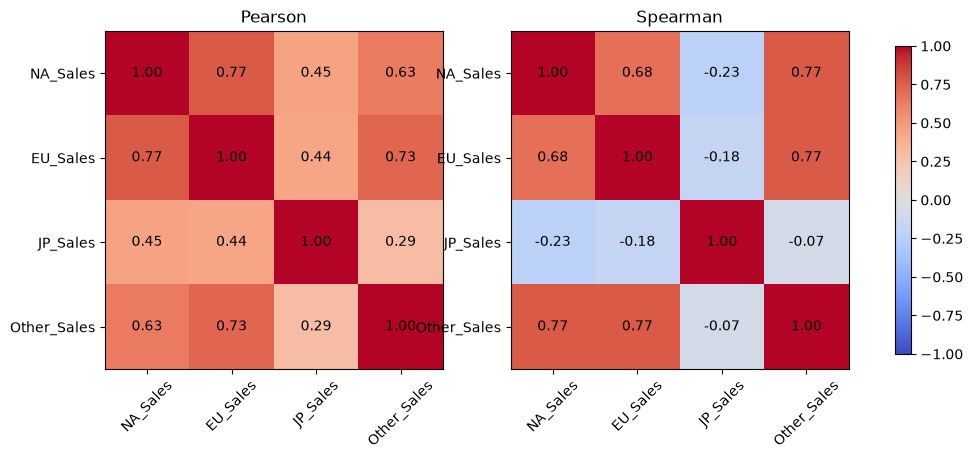

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for i, (mat, nome) in enumerate([(pearson, "Pearson"), (spearman, "Spearman")]):
    im = ax[i].imshow(mat, cmap="coolwarm", vmin=-1, vmax=1)
    ax[i].set_xticks(range(4), regioes, rotation=45)
    ax[i].set_yticks(range(4), regioes)
    for r in range(4):
        for c in range(4):
            ax[i].text(c, r, f"{mat.iloc[r, c]:.2f}", ha="center", va="center")
    ax[i].set_title(nome)

fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

### 5.1 O efeito dos grandes sucessos

Para testar se Pearson depende dos títulos gigantes, recalculamos a correlação sem o 1% mais vendido.

In [16]:
corte = vendas.quantile(0.99)
sem_top = df[df["Global_Sales"] < corte]

comparativo = pd.DataFrame({
    "Pearson (todos)":      pearson["NA_Sales"],
    "Pearson (sem top 1%)": sem_top[regioes].corr()["NA_Sales"],
    "Spearman (todos)":     spearman["NA_Sales"],
    "Spearman (sem top 1%)": sem_top[regioes].corr(method="spearman")["NA_Sales"],
}).drop("NA_Sales")

print(f"Corte do top 1%: {corte:.2f} M ({len(df) - len(sem_top)} títulos removidos)")
comparativo.round(2)

Corte do top 1%: 5.47 M (163 títulos removidos)


,Pearson (todos),Pearson (sem top 1%),Spearman (todos),Spearman (sem top 1%)
EU_Sales,0.77,0.63,0.68,0.67
JP_Sales,0.45,0.11,-0.23,-0.26
Other_Sales,0.63,0.54,0.77,0.77


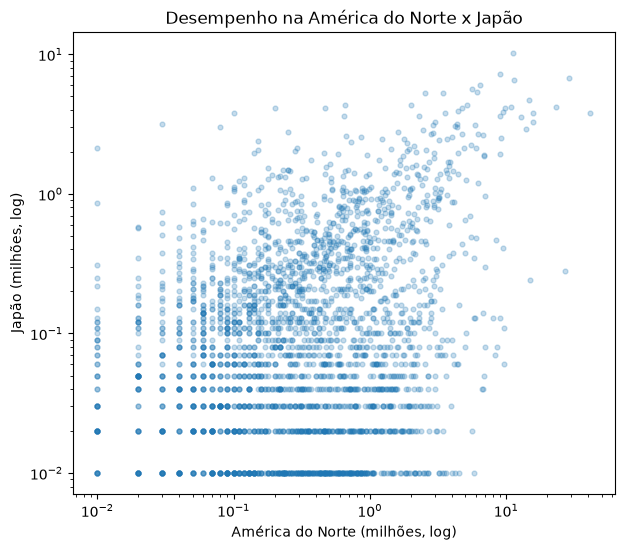

Títulos com venda zero no Japão: 62.7%


In [17]:
nj = df[(df["NA_Sales"] > 0) & (df["JP_Sales"] > 0)]

plt.figure(figsize=(7, 6))
plt.scatter(nj["NA_Sales"], nj["JP_Sales"], alpha=0.25, s=12)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("América do Norte (milhões, log)")
plt.ylabel("Japão (milhões, log)")
plt.title("Desempenho na América do Norte x Japão")
plt.show()

print(f"Títulos com venda zero no Japão: {(df['JP_Sales'] == 0).mean() * 100:.1f}%")

### 5.2 Quantos títulos grandes bastam para mudar a correlação?

In [18]:
top10 = df.nlargest(10, "Global_Sales")
print(top10[["Name", "Platform", "NA_Sales", "JP_Sales"]])

sem_top10 = df.drop(top10.index)
print(f"\nPearson NA x JP com todos:     {df['NA_Sales'].corr(df['JP_Sales']):.3f}")
print(f"Pearson NA x JP sem os top 10: {sem_top10['NA_Sales'].corr(sem_top10['JP_Sales']):.3f}")

                        Name Platform  NA_Sales  JP_Sales
0                 Wii Sports      Wii     41.49      3.77
1          Super Mario Bros.      NES     29.08      6.81
2             Mario Kart Wii      Wii     15.85      3.79
3          Wii Sports Resort      Wii     15.75      3.28
4   Pokemon Red/Pokemon Blue       GB     11.27     10.22
5                     Tetris       GB     23.20      4.22
6      New Super Mario Bros.       DS     11.38      6.50
7                   Wii Play      Wii     14.03      2.93
8  New Super Mario Bros. Wii      Wii     14.59      4.70
9                  Duck Hunt      NES     26.93      0.28

Pearson NA x JP com todos:     0.451
Pearson NA x JP sem os top 10: 0.368


### 5.3 Por que Spearman fica negativo com o Japão?

A hipótese é que boa parte do catálogo é vendida em só um dos dois mercados. Verificamos isso e recalculamos Spearman só entre títulos vendidos nas duas regiões.

In [19]:
print(pd.crosstab(df["NA_Sales"] > 0, df["JP_Sales"] > 0,
                  rownames=["Vende na NA"], colnames=["Vende no JP"]))

ambos = df[(df["NA_Sales"] > 0) & (df["JP_Sales"] > 0)]
print(f"\nTítulos vendidos nas duas regiões: {len(ambos)} ({len(ambos) / len(df) * 100:.1f}%)")
print(f"Spearman NA x JP só entre eles: {ambos['NA_Sales'].corr(ambos['JP_Sales'], method='spearman'):.3f}")

part = df.groupby("Genre", observed=True)[regioes].sum()
(part / part.sum() * 100).round(1)

Vende no JP  False  True 
Vende na NA              
False         1012   3417
True          9194   2667

Títulos vendidos nas duas regiões: 2667 (16.4%)
Spearman NA x JP só entre eles: 0.209


,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Genre,,,,
Action,19.9,21.5,12.4,23.4
Adventure,2.4,2.6,4.0,2.1
Fighting,5.1,4.2,6.8,4.6
Misc,9.2,8.8,8.3,9.4
Platform,10.3,8.3,10.2,6.5
Puzzle,2.8,2.1,4.4,1.6
Racing,8.2,9.8,4.4,9.7
Role-Playing,7.5,7.8,27.3,7.5
Shooter,13.3,12.9,3.0,12.9


**Conclusão da Pergunta 2.**

América do Norte, Europa e Outras regiões se movem juntas: as correlações entre elas ficam entre 0,63 e 0,77, tanto em Pearson quanto em Spearman. Um jogo que vende bem em uma dessas regiões tende a vender bem nas outras.

O Japão é diferente. Entre NA e JP, Pearson dá **+0,45**, mas Spearman dá **−0,23**. Essa relação positiva vem só dos grandes sucessos: sem o top 1% dos títulos, o Pearson cai para 0,11, enquanto o Spearman quase não muda.

O motivo é que 62,7% dos jogos não vendem nada no Japão, e só 16,4% vendem nas duas regiões. O gosto também é outro: RPG é 27,3% das vendas no Japão contra 7,5% na América do Norte, e Shooter é 13,3% na NA contra apenas 3,0% no Japão.

**A Hipótese 2 se confirma.** O desempenho se repete entre NA, EU e Outras regiões, mas o Japão tem dinâmica própria. Só os grandes sucessos globais vendem bem em todos os mercados.

## 6. Volume de lançamentos significa desempenho? (Pergunta 3)

### 6.1 Comparação por gênero

In [20]:
por_genero = (df.groupby("Genre", observed=True)["Global_Sales"]
                .agg(lancamentos="count", media="mean", mediana="median", desvio="std", total="sum")
                .sort_values("lancamentos", ascending=False))
por_genero["cv_%"] = por_genero["desvio"] / por_genero["media"] * 100
por_genero.round(3)

,lancamentos,media,mediana,desvio,total,cv_%
Genre,,,,,,
Action,3251,0.530,0.190,1.165,1722.84,219.880
Sports,2303,0.568,0.220,2.105,1309.23,370.342
Misc,1686,0.468,0.160,1.332,789.87,284.351
Role-Playing,1470,0.628,0.190,1.717,923.83,273.281
Shooter,1282,0.800,0.230,1.834,1026.20,229.063
Adventure,1274,0.184,0.060,0.511,234.59,277.458
Racing,1225,0.593,0.190,1.677,726.76,282.732
Platform,875,0.948,0.280,2.600,829.13,274.378
Simulation,848,0.460,0.160,1.207,389.98,262.552


### 6.2 Normalização

Queremos comparar número de lançamentos (contagem na casa dos milhares) com mediana de vendas (milhões, na casa dos décimos). Sem transformação, as escalas são incompatíveis e a mediana some no gráfico.

Usamos a **normalização robusta**: subtraímos a mediana e dividimos pelo intervalo interquartil, `(x − mediana) / IQR`. Escolhemos essa técnica em vez do z-score porque a Pergunta 1 mostrou outliers extremos, e média e desvio padrão seriam distorcidos por eles. Mediana e IQR não são.

In [21]:
comp = por_genero[["lancamentos", "mediana"]]
iqr_comp = comp.quantile(0.75) - comp.quantile(0.25)
norm = (comp - comp.median()) / iqr_comp

norm["saturacao"] = norm["lancamentos"] - norm["mediana"]
norm.sort_values("saturacao", ascending=False).round(2)

,lancamentos,mediana,saturacao
Genre,,,
Action,2.95,0.00,2.95
Adventure,0.04,-1.96,2.00
Sports,1.55,0.45,1.10
Misc,0.64,-0.45,1.10
Strategy,-0.85,-1.51,0.66
Role-Playing,0.32,0.00,0.32
Puzzle,-1.00,-1.28,0.28
Racing,-0.04,0.00,-0.04
Simulation,-0.59,-0.45,-0.14


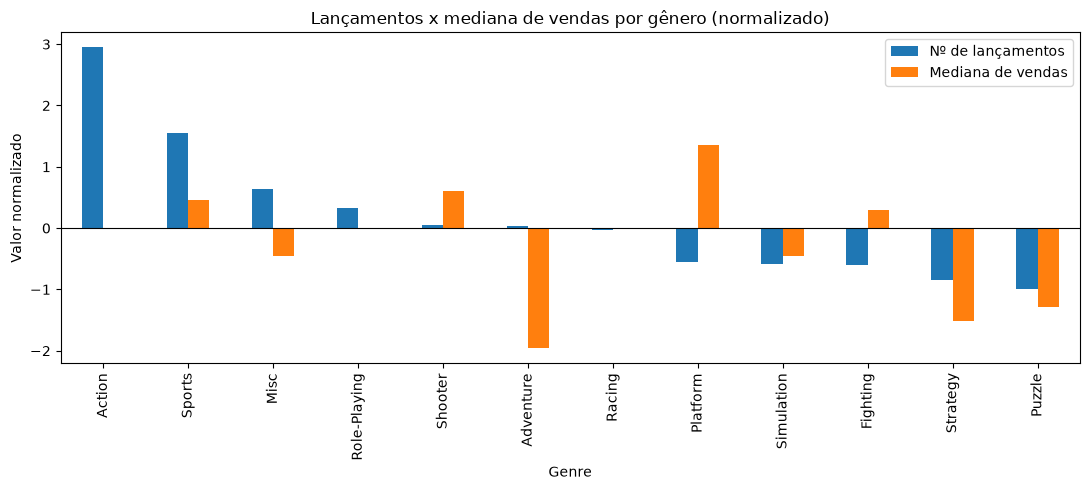

In [22]:
ax = (norm[["lancamentos", "mediana"]]
        .rename(columns={"lancamentos": "Nº de lançamentos", "mediana": "Mediana de vendas"})
        .sort_values("Nº de lançamentos", ascending=False)
        .plot(kind="bar", figsize=(11, 5)))
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Lançamentos x mediana de vendas por gênero (normalizado)")
ax.set_ylabel("Valor normalizado")
plt.tight_layout()
plt.show()

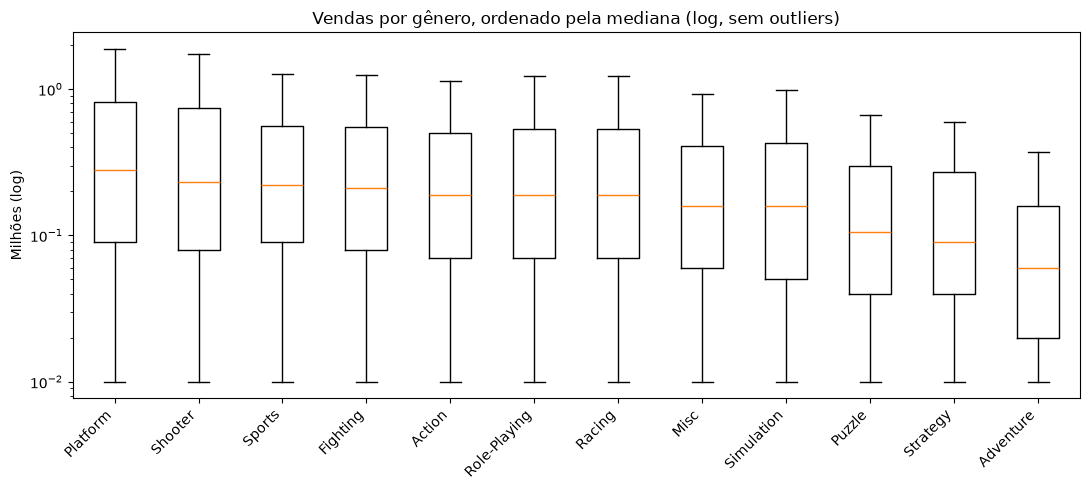

In [23]:
ordem = por_genero.sort_values("mediana", ascending=False).index
dados = [df.loc[df["Genre"] == g, "Global_Sales"] for g in ordem]

plt.figure(figsize=(11, 5))
plt.boxplot(dados, tick_labels=list(ordem), showfliers=False)
plt.yscale("log")
plt.xticks(rotation=45, ha="right")
plt.title("Vendas por gênero, ordenado pela mediana (log, sem outliers)")
plt.ylabel("Milhões (log)")
plt.tight_layout()
plt.show()

### 6.3 Comparação por plataforma

Consideramos só plataformas com pelo menos 100 títulos, porque mediana calculada sobre poucos lançamentos é instável.

In [24]:
por_plat = (df.groupby("Platform", observed=True)["Global_Sales"]
              .agg(lancamentos="count", mediana="median", total="sum"))
por_plat = por_plat[por_plat["lancamentos"] >= 100].sort_values("lancamentos", ascending=False)
por_plat.round(3)

,lancamentos,mediana,total
Platform,,,
DS,2131,0.110,818.91
PS2,2127,0.230,1233.46
PS3,1303,0.290,949.34
Wii,1290,0.200,909.81
X360,1234,0.290,969.60
PSP,1197,0.090,291.71
PS,1189,0.260,727.39
PC,938,0.040,254.70
XB,803,0.140,252.09


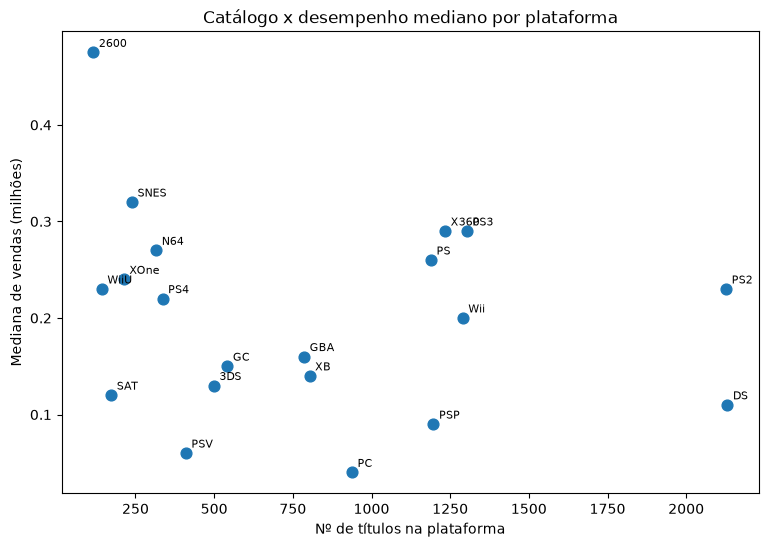

In [25]:
plt.figure(figsize=(9, 6))
plt.scatter(por_plat["lancamentos"], por_plat["mediana"], s=60)
for nome, linha in por_plat.iterrows():
    plt.annotate(nome, (linha["lancamentos"], linha["mediana"]), xytext=(4, 4), textcoords="offset points", fontsize=8)
plt.xlabel("Nº de títulos na plataforma")
plt.ylabel("Mediana de vendas (milhões)")
plt.title("Catálogo x desempenho mediano por plataforma")
plt.show()

### 6.4 Volume e mediana estão correlacionados?

In [26]:
print(f"Gêneros (n={len(por_genero)}):     Spearman = {por_genero['lancamentos'].corr(por_genero['mediana'], method='spearman'):.2f}")
print(f"Plataformas (n={len(por_plat)}): Spearman = {por_plat['lancamentos'].corr(por_plat['mediana'], method='spearman'):.2f}")

Gêneros (n=12):     Spearman = 0.31
Plataformas (n=20): Spearman = -0.21


**Conclusão da Pergunta 3.**

Lançar mais jogos não significa vender mais por jogo. A correlação de Spearman entre número de títulos e mediana de vendas é fraca nos gêneros (0,31) e levemente negativa nas plataformas (−0,21).

Action é o gênero com mais lançamentos (3.251), mas sua mediana (0,19 M) fica no meio da tabela. Platform tem bem menos títulos (875) e a maior mediana (0,28 M). Adventure é o caso mais claro de saturação: 1.274 títulos e a menor mediana de todas (0,06 M).

Nas plataformas acontece o mesmo. DS e PS2 têm quase o mesmo número de jogos (cerca de 2.130), mas a mediana do PS2 (0,23 M) é o dobro da do DS (0,11 M).

**A Hipótese 3 se confirma parcialmente.** Volume não garante desempenho, e existem gêneros e plataformas saturados. Porém, ter poucos lançamentos também não garante bom resultado: Strategy e Puzzle têm catálogos pequenos e medianas baixas. O que pesa é o apelo do tipo de jogo, não a quantidade de concorrentes.

## 7. Conclusão

**H1, confirmada.** As vendas são extremamente assimétricas (assimetria 17,3): mais de 75% dos títulos vendem abaixo da média, e 6% dos títulos concentram quase metade das vendas. A mediana (0,17 M) é a referência realista para um lançamento, não a média.

**H2, confirmada.** NA, EU e Outras regiões se movem juntas. O Japão tem dinâmica própria: Pearson e Spearman apontam em direções opostas, e a correlação positiva desaparece quando se retiram os grandes sucessos.

**H3, parcialmente confirmada.** Volume de lançamentos não se traduz em desempenho típico, mas catálogo pequeno também não garante mediana alta.

**Limitações.** Os dados são estimativas de varejo físico, sem vendas digitais, o que subestima os anos recentes. A base só inclui títulos acima de cerca de 100 mil cópias, então os fracassos comerciais ficam de fora (viés de sobrevivência): a assimetria real do mercado é provavelmente ainda maior. Registros a partir de 2016 estão incompletos.